In [ ]:
!pip install mordred
!pip install pandas requests
!pip install rdkit
!pip install torch_geometric

## Pre-processing the dataset

### Here, we are using the full dataset, not the normalized one

In [ ]:
import pandas as pd

df = pd.read_csv("7Q27.sensograms.csv")

In [ ]:
df.head()

,record_seq_num,relative_time_sec,unix_timestamp_sec,run_id,run_name,device_id,item,cycle,section,humidity,temperature,1,105,106,24,25,34,36,55
0,0,0.000,1.775659e+09,2604081640,2604081640,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,baseline,0.0,27.72,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
1,0,0.333,1.775659e+09,2604081640,2604081640,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,baseline,0.0,27.74,0.00290,0.01150,0.007450,0.002045,0.004000,0.006000,0.00560,-0.00415
2,0,0.666,1.775659e+09,2604081640,2604081640,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,baseline,0.0,27.72,0.01535,0.01455,0.015745,0.012000,0.010745,0.011495,0.00860,0.00350
3,0,0.999,1.775659e+09,2604081640,2604081640,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,baseline,0.0,27.72,0.03765,0.02005,0.020395,0.015295,0.014350,0.012800,0.01790,0.00510
4,0,1.665,1.775659e+09,2604081640,2604081640,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,baseline,0.0,27.74,0.03990,0.03235,0.027350,0.028295,0.018745,0.019845,0.02339,0.01290


In [ ]:
readings = df[['record_seq_num', 'item', '1', '105', '106', '24', '25', '34', '36', '55']]
display(readings.head())

,record_seq_num,item,1,105,106,24,25,34,36,55
0,0,Ocimene_080426,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
1,0,Ocimene_080426,0.00290,0.01150,0.007450,0.002045,0.004000,0.006000,0.00560,-0.00415
2,0,Ocimene_080426,0.01535,0.01455,0.015745,0.012000,0.010745,0.011495,0.00860,0.00350
3,0,Ocimene_080426,0.03765,0.02005,0.020395,0.015295,0.014350,0.012800,0.01790,0.00510
4,0,Ocimene_080426,0.03990,0.03235,0.027350,0.028295,0.018745,0.019845,0.02339,0.01290


In [ ]:
examples = []

for i in range(readings['record_seq_num'].nunique()):
  filtered_example = readings[readings['record_seq_num'] == i]
  examples.append(filtered_example)

### Plotting all the different signatures of all the experiments in the dataset

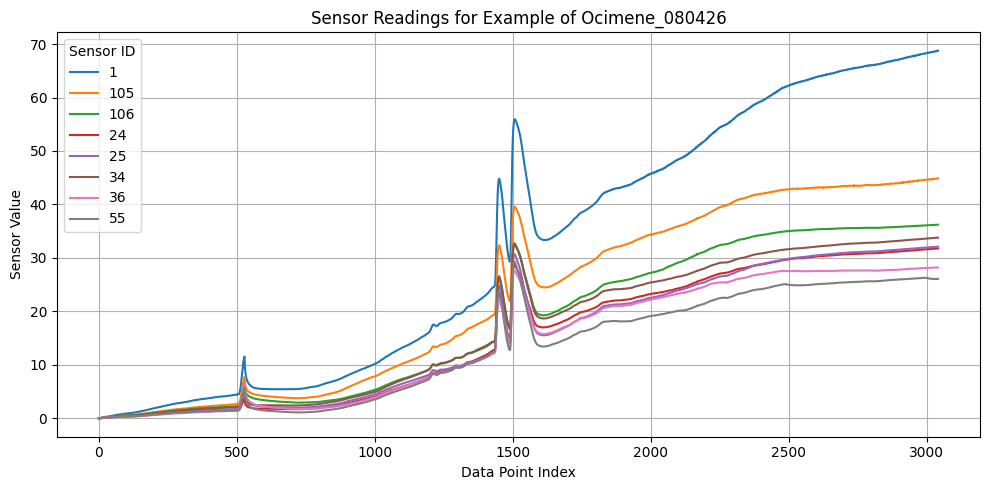

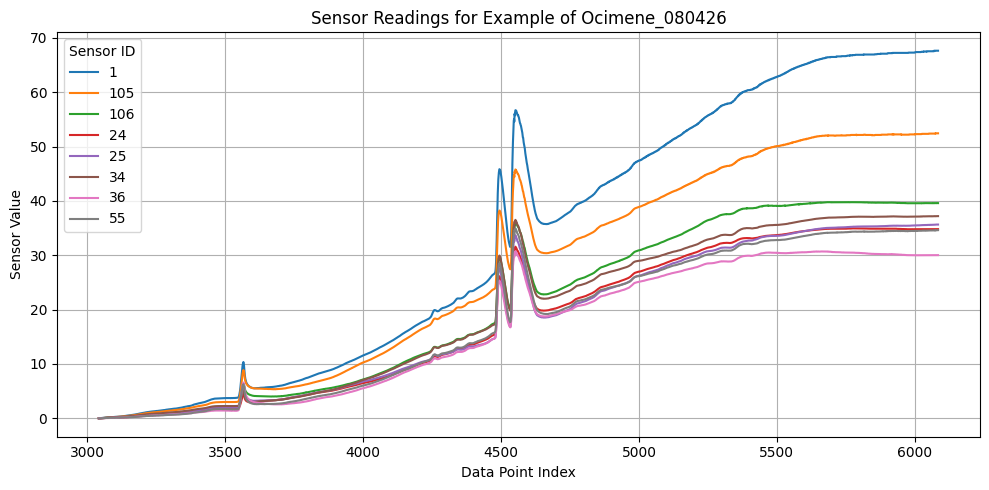

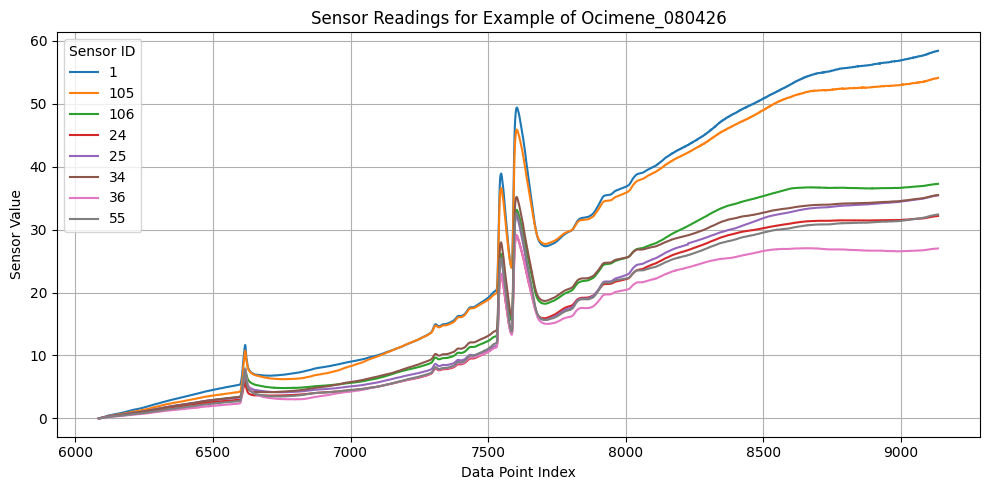

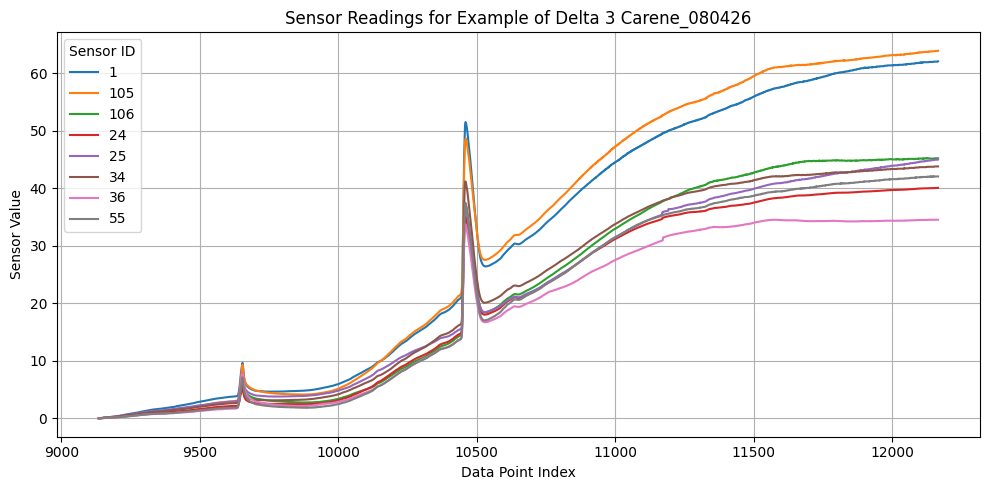

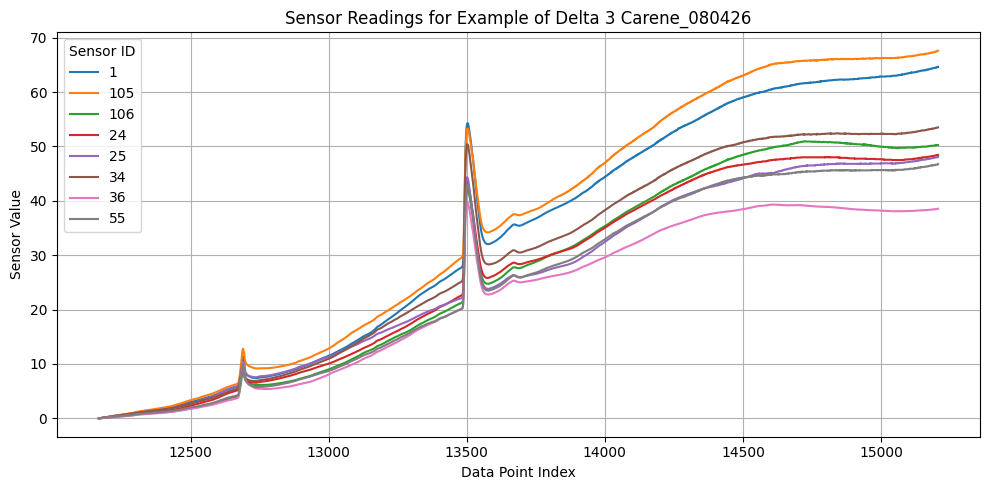

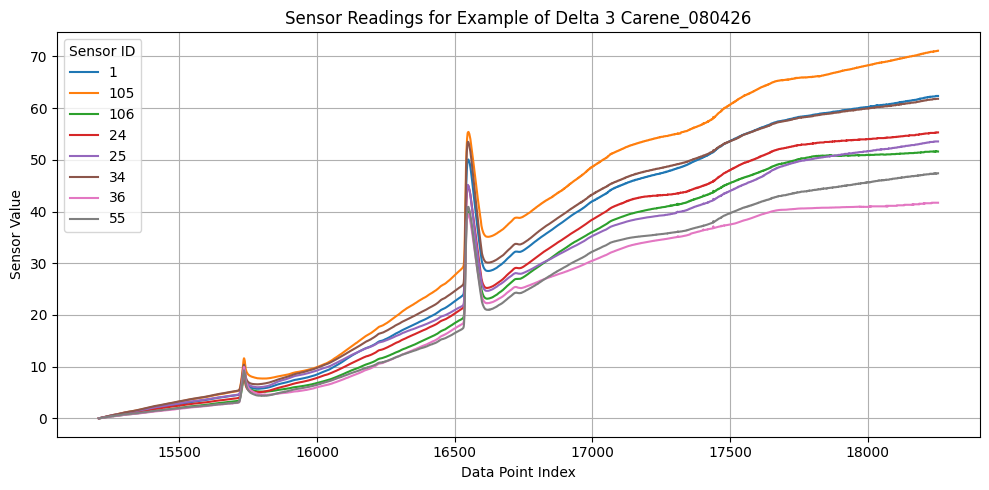

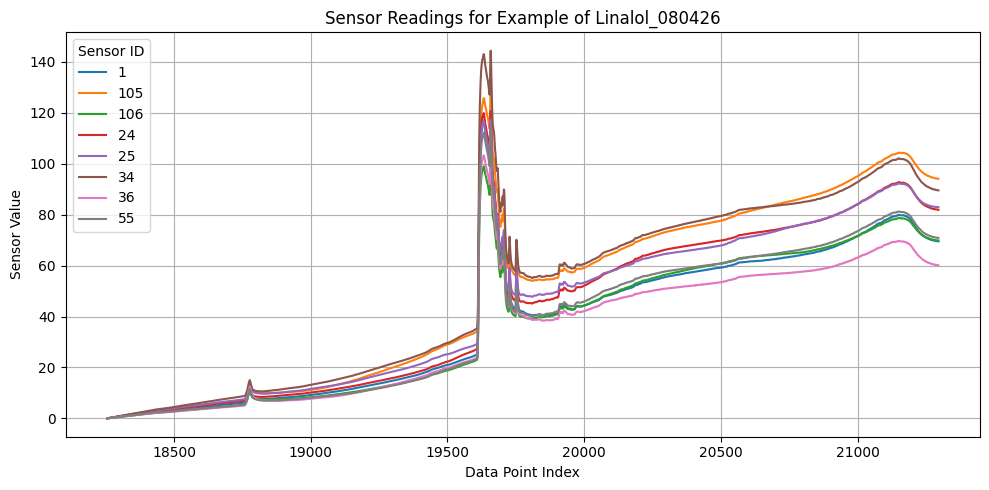

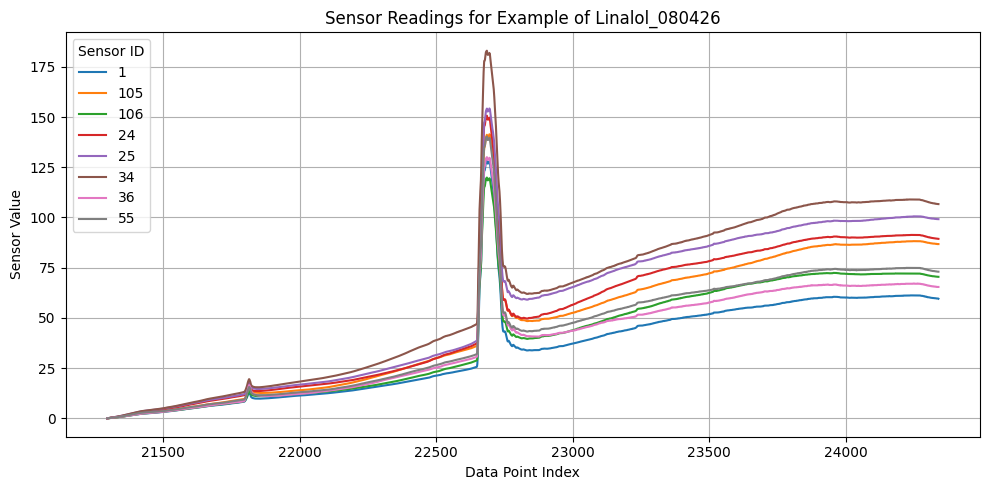

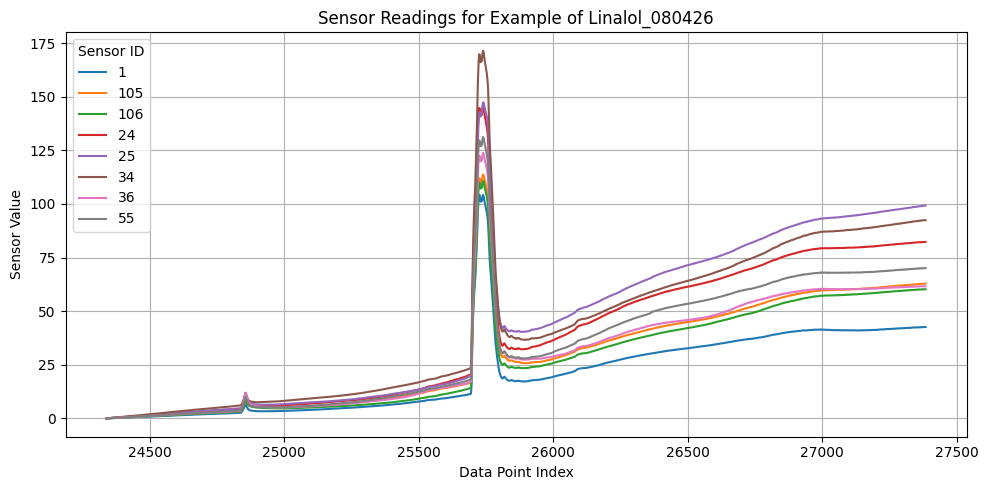

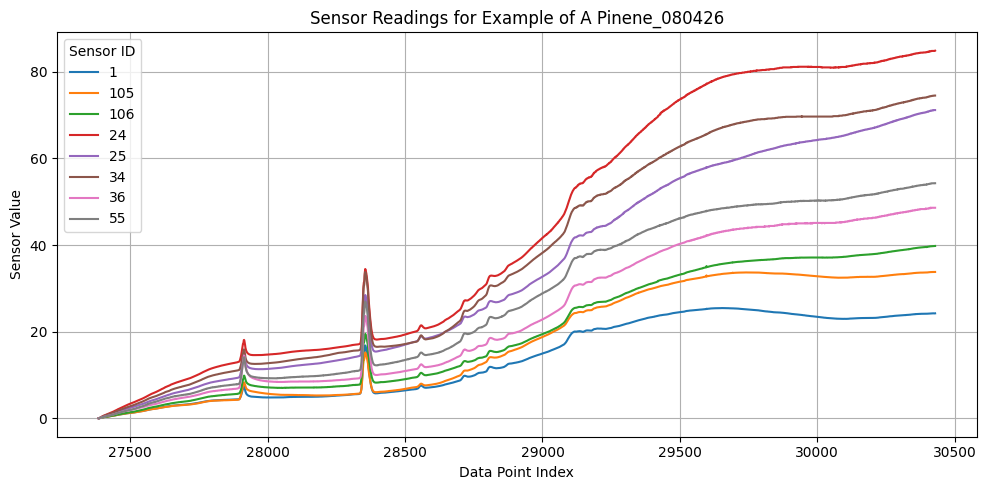

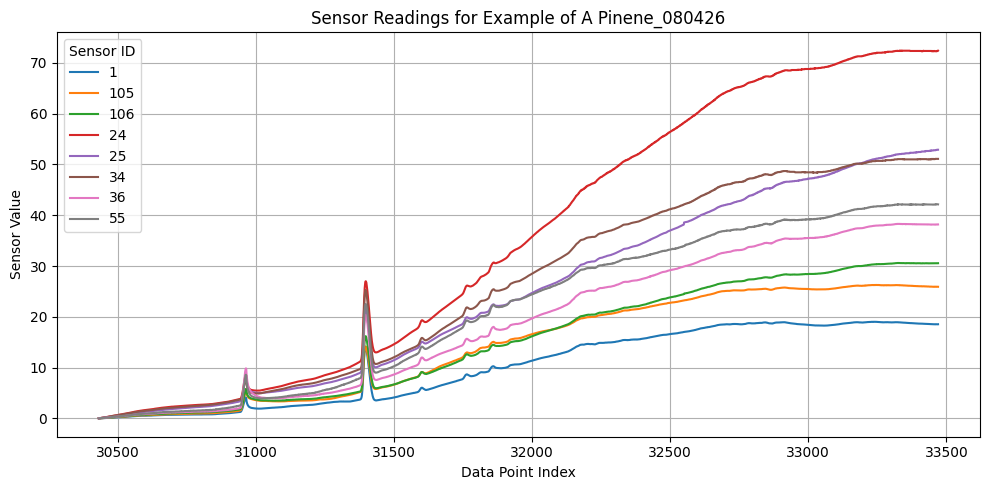

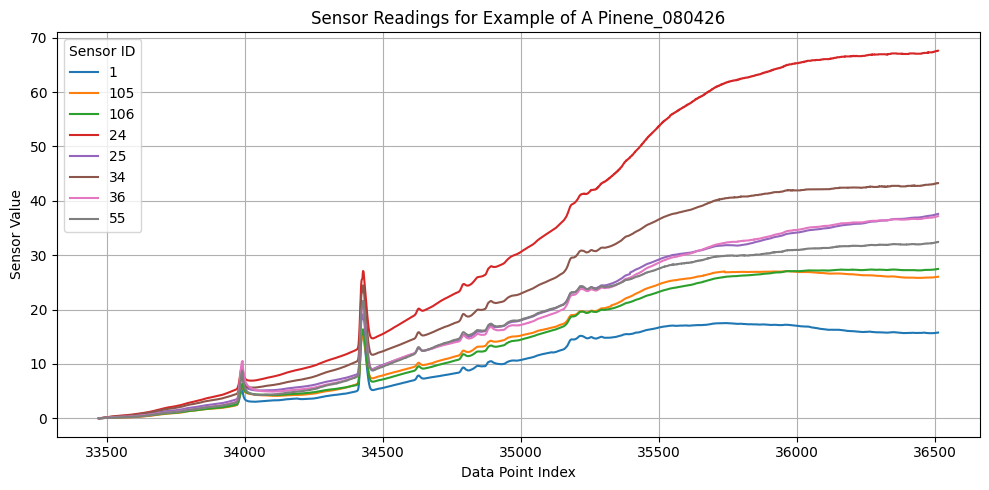

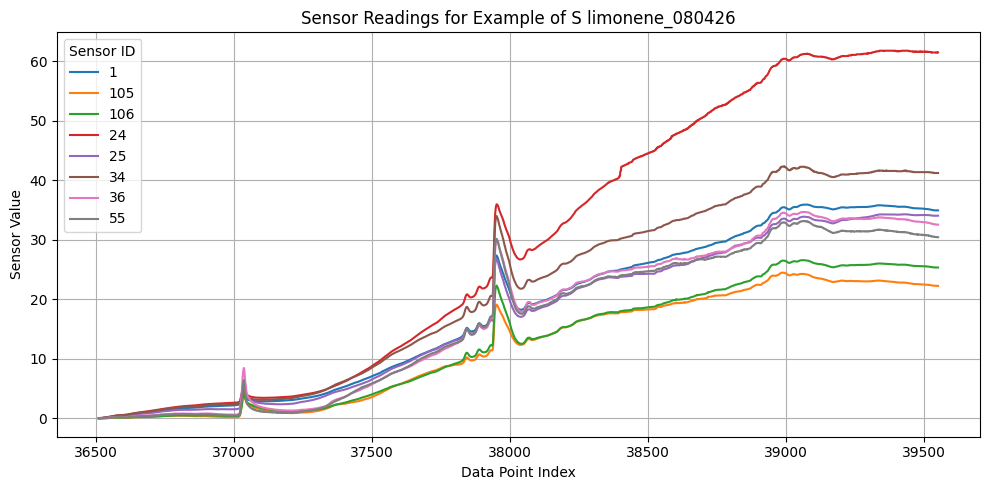

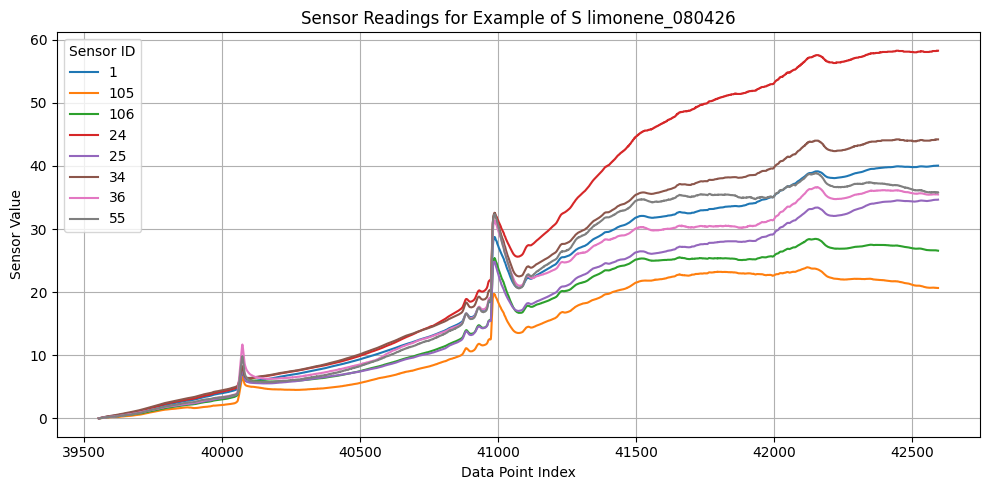

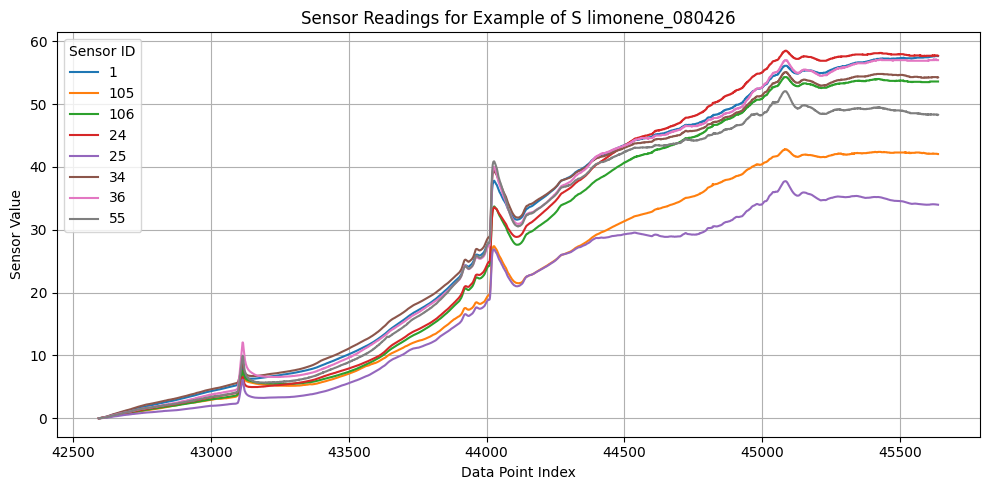

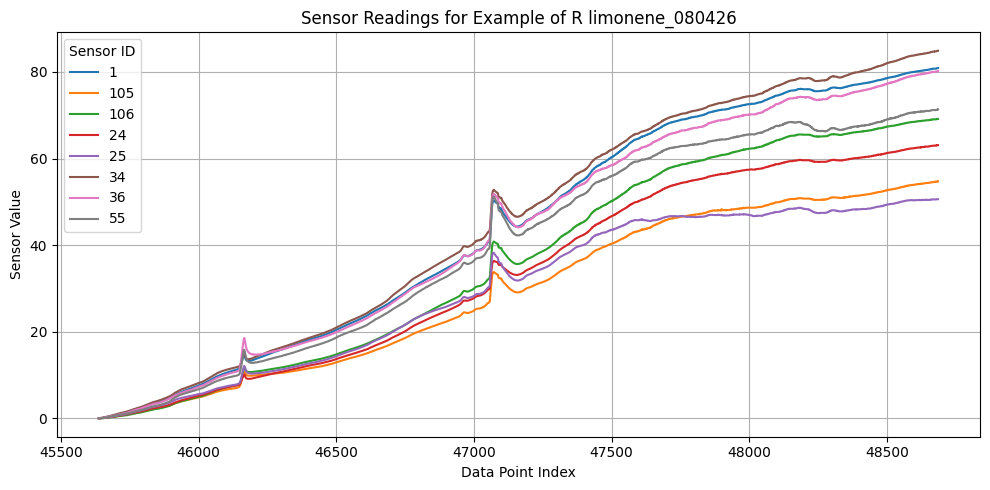

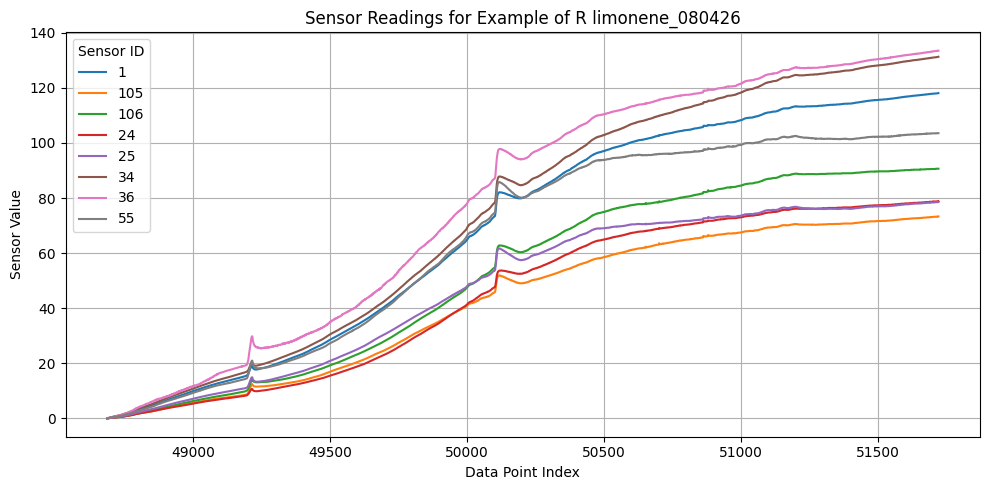

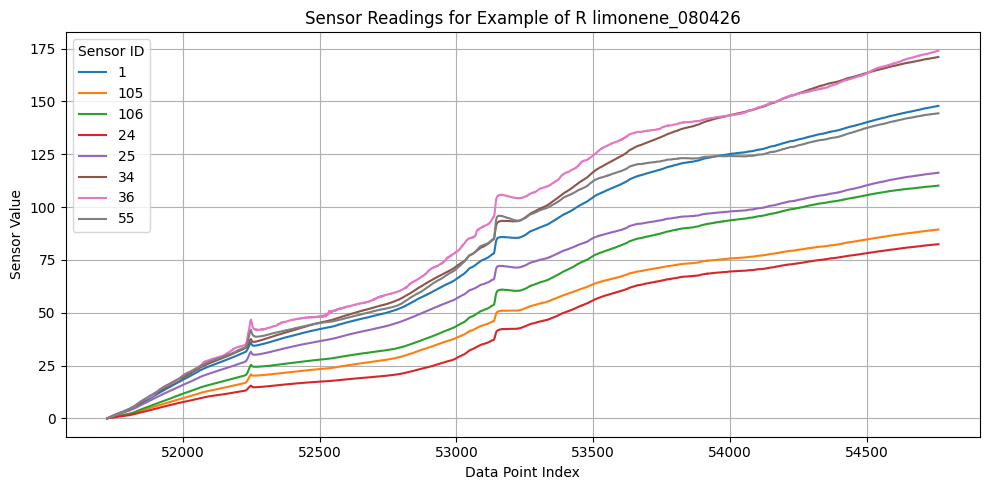

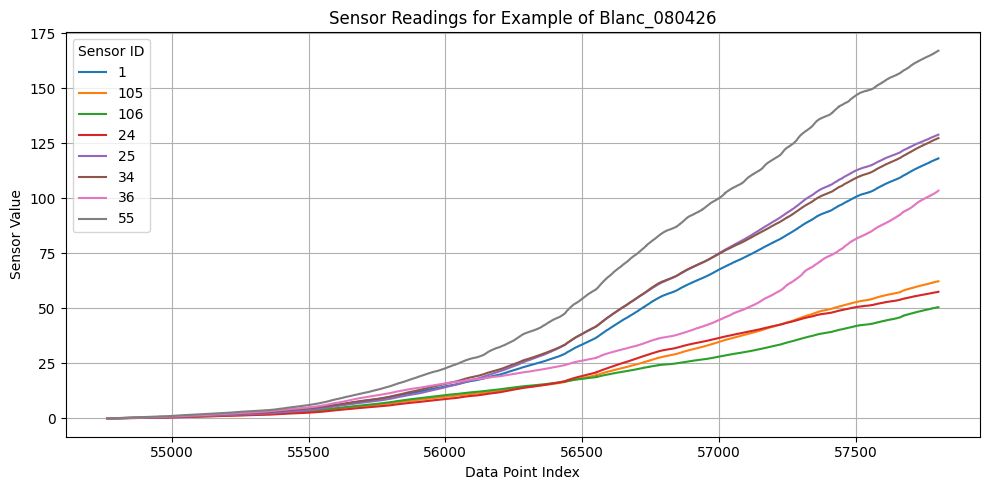

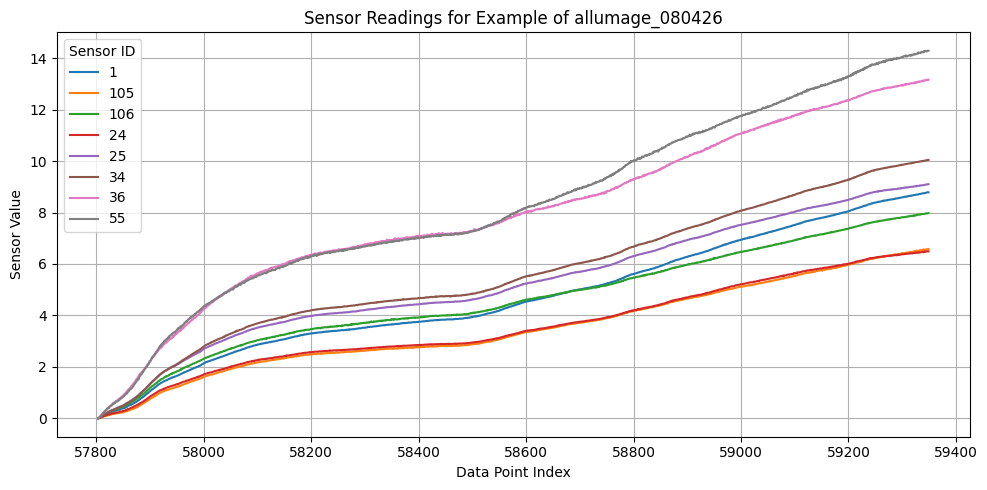

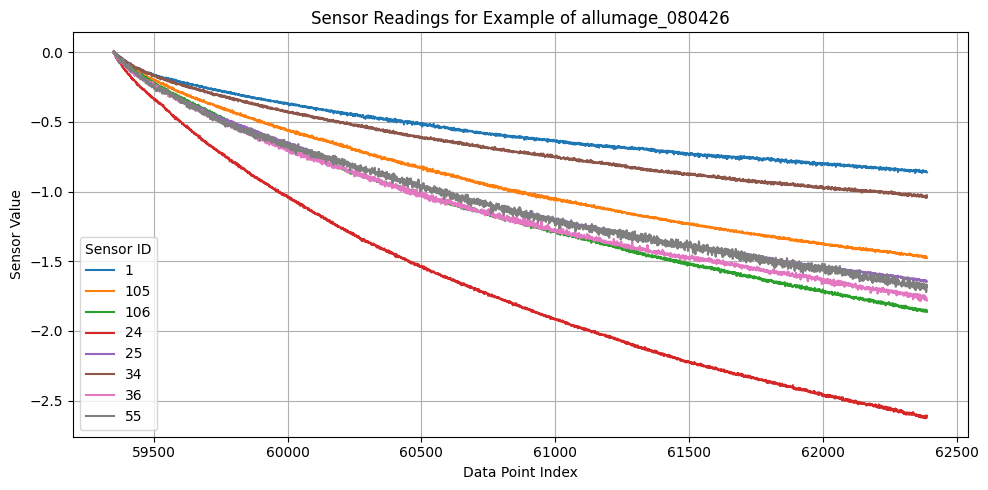

In [ ]:
import matplotlib.pyplot as plt

for i, example_df in enumerate(examples):
    cols_to_plot = [col for col in example_df.columns if col != 'record_seq_num']
    cols_to_plot = [col for col in cols_to_plot if col != 'item']

    plt.figure(figsize=(10, 5))
    for col in cols_to_plot:
        plt.plot(example_df.index, example_df[col], label=col)

    plt.title(f'Sensor Readings for Example of {examples[i]['item'].iloc[0]}')
    plt.xlabel('Data Point Index')
    plt.ylabel('Sensor Value')
    plt.legend(loc='best', title='Sensor ID')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Extracting features

### Converting the name of the molecules to a SMILES representation

So we first convert the names of the molecules to a representation that exists in the PubChem dictionary using their API, and then we pull the SMILES representation of that molecule from there. If the molecule is not in a format that can be automatically pulled from the dictionary, we add the name manually in a separate dictionary called `'manual_name_mapping'` in which in the following runs of the cell, the name of the molecules in that dictionary will already be converted to the accepted format. After everything is correctly formated, just then we do the convertions to SMILES.

In [ ]:
import pandas as pd
import requests
import time

manual_name_mapping = {
    "s-limonene": "(-)-limonene",
    "r-limonene": "(r)-(+)-limonene"
}

def get_smiles_from_pubchem(molecule_name):
    """
    Queries the PubChem REST API to get the Isomeric SMILES string for a given molecule name.
    """
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{molecule_name}/property/IsomericSMILES/JSON"

    try:
        response = requests.get(url)
        if response.status_code == 200:
            data = response.json()
            smiles = data['PropertyTable']['Properties'][0].get('SMILES')
            return smiles
        else:
            print(f"  [!] Could not find SMILES for '{molecule_name}' (Status code: {response.status_code})")
            return None
    except requests.exceptions.RequestException as e:
        print(f"  [!] Network error when querying '{molecule_name}': {e}")
        return None

input_file = '7Q27.normalized.signatures.csv'
output_file = '7Q27.normalized.signatures_with_smiles.csv'

print(f"Loading dataset from {input_file}...")
df = pd.read_csv(input_file)

# Making a copy of the last 3 rows and removing them, since they are useless for the rest of the processes here
df_last_3_rows = df.tail(3)
df = df.head(-3)

print("Cleaning molecule names...")
df['cleaned_item'] = df['item'].astype(str).apply(
    lambda x: x.split('_')[0].strip().lower().replace(' ', '-')
)

df['query_item'] = df['cleaned_item'].apply(
    lambda x: manual_name_mapping.get(x, x)
)

unique_items = df['query_item'].unique()
print(f"Found {len(unique_items)} unique items to query. Fetching SMILES from PubChem...")

smiles_dictionary = {}
for item in unique_items:
    if item in ['blanc', 'allumage']:
        smiles_dictionary[item] = None
        continue

    print(f"  Querying: {item}")
    smiles_dictionary[item] = get_smiles_from_pubchem(item)

    time.sleep(0.25)

print("Mapping SMILES back to the dataset...")
df['SMILES'] = df['query_item'].map(smiles_dictionary)

df = df.drop(columns=['query_item'])

# df.to_csv(output_file, index=False)
print(f"Done! Updated dataset saved to '{output_file}'.")

Loading dataset from 7Q27.normalized.signatures.csv...
Cleaning molecule names...
Found 6 unique items to query. Fetching SMILES from PubChem...
  Querying: ocimene
  Querying: delta-3-carene
  Querying: linalol
  Querying: a-pinene
  Querying: (-)-limonene
  Querying: (r)-(+)-limonene
Mapping SMILES back to the dataset...
Done! Updated dataset saved to '7Q27.normalized.signatures_with_smiles.csv'.


In [ ]:
df['SMILES']

,SMILES
0,CC(C)/C=C/C=C(\C)/C=C
1,CC(C)/C=C/C=C(\C)/C=C
2,CC(C)/C=C/C=C(\C)/C=C
3,CC1=CCC2C(C1)C2(C)C
4,CC1=CCC2C(C1)C2(C)C
5,CC1=CCC2C(C1)C2(C)C
6,CC(=CCCC(C)(C=C)O)C
7,CC(=CCCC(C)(C=C)O)C
8,CC(=CCCC(C)(C=C)O)C
9,CC1=C[C@H]2C[C@@H](C1)C2(C)C


Smiles dictionary:

In [ ]:
smiles_dictionary

{'ocimene': 'CC(C)/C=C/C=C(\\C)/C=C',
 'delta-3-carene': 'CC1=CCC2C(C1)C2(C)C',
 'linalol': 'CC(=CCCC(C)(C=C)O)C',
 'a-pinene': 'CC1=C[C@H]2C[C@@H](C1)C2(C)C',
 '(-)-limonene': 'CC1=CC[C@H](CC1)C(=C)C',
 '(r)-(+)-limonene': 'CC1=CC[C@@H](CC1)C(=C)C'}

### Extracting the Morgan Fingerprints

In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=512, includeChirality=True)

def get_morgan_fingerprint_v2(smiles):
    """
    Converts a SMILES string into a Morgan fingerprint as a NumPy array
    using the modern MorganGenerator.
    """
    # Check if the SMILES is NaN or empty
    if pd.isna(smiles):
        return None

    # Create RDKit molecule object
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None

    # 2. Generate the fingerprint directly as a NumPy array of 0s and 1s
    fp_array = morgan_gen.GetFingerprintAsNumPy(mol)

    return fp_array

# Apply the function to the 'SMILES' column
df['Morgan_FP'] = df['SMILES'].apply(get_morgan_fingerprint_v2)

print(df[['cleaned_item', 'SMILES', 'Morgan_FP']].head(10))

     cleaned_item                        SMILES  \
0         ocimene         CC(C)/C=C/C=C(\C)/C=C   
1         ocimene         CC(C)/C=C/C=C(\C)/C=C   
2         ocimene         CC(C)/C=C/C=C(\C)/C=C   
3  delta-3-carene           CC1=CCC2C(C1)C2(C)C   
4  delta-3-carene           CC1=CCC2C(C1)C2(C)C   
5  delta-3-carene           CC1=CCC2C(C1)C2(C)C   
6         linalol           CC(=CCCC(C)(C=C)O)C   
7         linalol           CC(=CCCC(C)(C=C)O)C   
8         linalol           CC(=CCCC(C)(C=C)O)C   
9        a-pinene  CC1=C[C@H]2C[C@@H](C1)C2(C)C   

                                           Morgan_FP  
0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
1  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
2  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
3  [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...  
4  [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...  
5  [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...  
6  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ... 

In [ ]:
len(df["Morgan_FP"][0]), print(df["Morgan_FP"][0])

[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 

(512, None)

### Extracting the MACCS fingerprints

In [ ]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import MACCSkeys

def get_maccs_keys(smiles):
    # Check for NaN/empty values
    if pd.isna(smiles):
        return None

    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None

    # Generate the MACCS keys
    maccs_fp = MACCSkeys.GenMACCSKeys(mol)

    # Convert directly to a NumPy array of 0s and 1s
    return np.array(maccs_fp)

# Apply to your dataframe
df['MACCS_FP'] = df['SMILES'].apply(get_maccs_keys)

print(df[['cleaned_item', 'SMILES', 'MACCS_FP']].head(10))

     cleaned_item                        SMILES  \
0         ocimene         CC(C)/C=C/C=C(\C)/C=C   
1         ocimene         CC(C)/C=C/C=C(\C)/C=C   
2         ocimene         CC(C)/C=C/C=C(\C)/C=C   
3  delta-3-carene           CC1=CCC2C(C1)C2(C)C   
4  delta-3-carene           CC1=CCC2C(C1)C2(C)C   
5  delta-3-carene           CC1=CCC2C(C1)C2(C)C   
6         linalol           CC(=CCCC(C)(C=C)O)C   
7         linalol           CC(=CCCC(C)(C=C)O)C   
8         linalol           CC(=CCCC(C)(C=C)O)C   
9        a-pinene  CC1=C[C@H]2C[C@@H](C1)C2(C)C   

                                            MACCS_FP  
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
5  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
6  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ... 

In [ ]:
df['MACCS_FP'][0]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0])

In [ ]:
df

,record_seq_num,unix_timestamp_sec,run_id,run_name,device_id,item,cycle,baseline_start_sec,baseline_end_sec,analyte_start_sec,...,106,24,25,34,36,55,cleaned_item,SMILES,Morgan_FP,MACCS_FP
0,0,1.775659e+09,2604081640,2604081640,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,0,9.99,10.323,...,0.331338,0.281003,0.281038,0.308008,0.262813,0.238051,ocimene,CC(C)/C=C/C=C(\C)/C=C,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1,1.775658e+09,2604081618,2604081618,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,0,9.99,10.323,...,0.334196,0.290782,0.289314,0.313109,0.263302,0.284833,ocimene,CC(C)/C=C/C=C(\C)/C=C,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,2,1.775657e+09,2604081556,2604081556,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,0,9.99,10.323,...,0.332771,0.285086,0.301563,0.321381,0.255588,0.283442,ocimene,CC(C)/C=C/C=C(\C)/C=C,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,3,1.775654e+09,2604081518,2604081518,NOA222-10002-3H5QU_fsp,Delta 3 Carene_080426,1,0,9.99,10.323,...,0.330214,0.301157,0.322543,0.331946,0.270023,0.304884,delta-3-carene,CC1=CCC2C(C1)C2(C)C,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,4,1.775653e+09,2604081459,2604081459,NOA222-10002-3H5QU_fsp,Delta 3 Carene_080426,1,0,9.99,10.323,...,0.334211,0.330728,0.320887,0.361776,0.276138,0.309890,delta-3-carene,CC1=CCC2C(C1)C2(C)C,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5,5,1.775652e+09,2604081440,2604081440,NOA222-10002-3H5QU_fsp,Delta 3 Carene_080426,1,0,9.99,10.323,...,0.325081,0.347647,0.332880,0.395040,0.275756,0.289977,delta-3-carene,CC1=CCC2C(C1)C2(C)C,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,6,1.775651e+09,2604081420,2604081420,NOA222-10002-3H5QU_fsp,Linalol_080426,1,0,9.99,10.323,...,0.310983,0.364879,0.368940,0.422110,0.287135,0.318845,linalol,CC(=CCCC(C)(C=C)O)C,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7,7,1.775650e+09,2604081400,2604081400,NOA222-10002-3H5QU_fsp,Linalol_080426,1,0,9.99,10.323,...,0.301203,0.380818,0.417551,0.455167,0.291514,0.318190,linalol,CC(=CCCC(C)(C=C)O)C,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
8,8,1.775649e+09,2604081341,2604081341,NOA222-10002-3H5QU_fsp,Linalol_080426,1,0,9.99,10.323,...,0.283891,0.398673,0.459304,0.440551,0.311318,0.345391,linalol,CC(=CCCC(C)(C=C)O)C,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9,9,1.775643e+09,2604081218,2604081218,NOA222-10002-3H5QU_fsp,A Pinene_080426,1,0,9.99,10.323,...,0.243274,0.527367,0.415860,0.460884,0.293844,0.339356,a-pinene,CC1=C[C@H]2C[C@@H](C1)C2(C)C,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."


### Extracting the Daylight fingerprints

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

# Initialize the RDKit (Daylight-style) Fingerprint Generator
# maxPath=7 is the Daylight standard. fpSize=2048 is the standard bit length.
rdk_gen = rdFingerprintGenerator.GetRDKitFPGenerator(maxPath=7, fpSize=512)

def get_daylight_style_fingerprint(smiles):
    if pd.isna(smiles):
        return None

    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None

    # Generate the fingerprint directly as a NumPy array
    return rdk_gen.GetFingerprintAsNumPy(mol)

# Apply to your dataframe
df['Daylight_Style_FP'] = df['SMILES'].apply(get_daylight_style_fingerprint)

In [ ]:
df["Daylight_Style_FP"].head()

,Daylight_Style_FP
0,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, ..."
1,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, ..."
2,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, ..."
3,"[0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, ..."
4,"[0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, ..."


### Extracting the LogP (Partition Coefficient)

In [ ]:
from rdkit.Chem import Descriptors

def get_slogp(smiles):
    if pd.isna(smiles): return None
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None: return None

    # Calculates the estimated LogP
    return Descriptors.MolLogP(mol)

df['LogP'] = df['SMILES'].apply(get_slogp)

In [ ]:
df['LogP'].head()

,LogP
0,3.3309
1,3.3309
2,3.3309
3,2.9987
4,2.9987


### Extracting the Mordred Molecular Descriptors

#### Using the 3D features + removing columns based on their correlation with another column, if a column has an correlation of, for example, 0.95 (threshold) with another one, one of them is dropped. Furthermore, if we have columns that are composed of mostly 1's or 0's, we also drop them, because they don't give us any usefull information

In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from mordred import Calculator, descriptors

# ==========================================
# PART 1: COMPUTE 2D + 3D DESCRIPTORS
# ==========================================
calc = Calculator(descriptors, ignore_3D=False)

def get_3d_mordred_descriptors(smiles):
    if pd.isna(smiles): return None
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None: return None

    mol = Chem.AddHs(mol)
    if AllChem.EmbedMolecule(mol, randomSeed=42) == -1: return None
    AllChem.MMFFOptimizeMolecule(mol)

    result = calc(mol)
    clean_result = result.fill_missing(np.nan)
    return list(clean_result.values())

print("Calculating Descriptors...")
df_valid = df.dropna(subset=['SMILES']).copy()
df_valid['Mordred_All'] = df_valid['SMILES'].apply(get_3d_mordred_descriptors)

# ==========================================
# PART 2: CLEAN UP ERRORS (NaNs)
# ==========================================
df_valid = df_valid.dropna(subset=['Mordred_All'])
X_features = pd.DataFrame(df_valid['Mordred_All'].tolist(), index=df_valid.index)
X_features.columns = list(calc._name_dict.keys())

# Drop mathematical NaNs
X_features_clean = X_features.dropna(axis=1)
print(f"Features after dropping NaNs: {X_features_clean.shape[1]}")

# ==========================================
# PART 3: REMOVE ZERO & LOW VARIANCE COLUMNS (NEW!)
# ==========================================
print("Filtering low variance columns...")

# Rule A: Drop strictly constant columns (e.g., all 0s)
# nunique() counts how many different values exist in a column. If it's 1, it's constant!
X_features_var = X_features_clean.loc[:, X_features_clean.nunique() > 1]

# Rule B: Drop "almost constant" columns (e.g., 99% of values are exactly the same)
# We calculate what percentage the most common value makes up in each column
variance_threshold = 0.95 # If a single value takes up > 95% of the column, drop it
cols_to_keep = []

for col in X_features_var.columns:
    # Get the frequency of the most common value as a percentage (0.0 to 1.0)
    most_frequent_pct = X_features_var[col].value_counts(normalize=True).iloc[0]

    if most_frequent_pct < variance_threshold:
        cols_to_keep.append(col)

X_features_var = X_features_var[cols_to_keep]

print(f"Features dropped due to zero/low variance: {X_features_clean.shape[1] - X_features_var.shape[1]}")
print(f"Features remaining: {X_features_var.shape[1]}")

# ==========================================
# PART 4: REMOVE HIGHLY CORRELATED COLUMNS
# ==========================================
print("Calculating correlation matrix...")

# Now we calculate correlation on the variance-filtered dataset
corr_matrix = X_features_var.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

correlation_threshold = 0.95
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > correlation_threshold)]

X_final = X_features_var.drop(columns=to_drop)

print(f"Features dropped due to high correlation: {len(to_drop)}")
print(f"FINAL NUMBER OF USEFUL FEATURES: {X_final.shape[1]}")

# You can now safely merge X_final with your original dataframe!
final_df = pd.concat([df_valid.drop(columns=['Mordred_All']), X_final], axis=1)

Calculating Descriptors...
Features after dropping NaNs: 1437
Filtering low variance columns...
Features dropped due to zero/low variance: 338
Features remaining: 1099
Calculating correlation matrix...
Features dropped due to high correlation: 1052
FINAL NUMBER OF USEFUL FEATURES: 47


In [ ]:
final_df.head()

,record_seq_num,unix_timestamp_sec,run_id,run_name,device_id,item,cycle,baseline_start_sec,baseline_end_sec,analyte_start_sec,...,MATS2d,MATS3s,GATS4c,GATS4s,C3SP2,Xch-3d,GeomShapeIndex,ZMIC3,MOMI-Z,PBF
0,0,1.775659e+09,2604081640,2604081640,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,0,9.99,10.323,...,-0.291091,-0.096053,1.035490,1.080931,1,0.000000,0.770499,17.574311,136.264377,0.492984
1,1,1.775658e+09,2604081618,2604081618,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,0,9.99,10.323,...,-0.291091,-0.096053,1.035490,1.080931,1,0.000000,0.770499,17.574311,136.264377,0.492984
2,2,1.775657e+09,2604081556,2604081556,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,0,9.99,10.323,...,-0.291091,-0.096053,1.035490,1.080931,1,0.000000,0.770499,17.574311,136.264377,0.492984
3,3,1.775654e+09,2604081518,2604081518,NOA222-10002-3H5QU_fsp,Delta 3 Carene_080426,1,0,9.99,10.323,...,-0.309641,-0.331508,0.757979,0.830350,1,0.166667,0.600918,17.989763,202.807015,0.826944
4,4,1.775653e+09,2604081459,2604081459,NOA222-10002-3H5QU_fsp,Delta 3 Carene_080426,1,0,9.99,10.323,...,-0.309641,-0.331508,0.757979,0.830350,1,0.166667,0.600918,17.989763,202.807015,0.826944


#### Calculating the 2D + 3D features without considering the correlation between columns

In [ ]:
# import pandas as pd
# from rdkit import Chem
# from mordred import Calculator, descriptors

# # 1. Initialize the Mordred Calculator
# # ignore_3D=True calculates only the ~1613 2D descriptors.
# # Calculating 3D descriptors requires generating 3D conformers first, which is very slow.
# calc = Calculator(descriptors, ignore_3D=False)

# def get_mordred_descriptors(smiles):
#     if pd.isna(smiles):
#         return None

#     mol = Chem.MolFromSmiles(str(smiles))
#     if mol is None:
#         return None

#     # 2. Calculate the descriptors (returns a Result object)
#     result = calc(mol)
#     result = result.fill_missing(np.nan)

#     # 3. Convert the result to a dictionary or list of values
#     # result.asdict() gives you { 'MW': 180.15, 'nAtoms': 21, ... }
#     return list(result.values())

# # Apply to your dataframe
# df['Mordred_Descriptors'] = df['SMILES'].apply(get_mordred_descriptors)

# # To see the names of all the features calculated:
# feature_names = list(calc._name_dict.keys())
# print(f"Calculated {len(feature_names)} features per molecule.")

In [ ]:
# import pandas as pd

# df_valid_mols = df.dropna(subset=['Mordred_Descriptors']).copy()

# X_features = pd.DataFrame(df_valid_mols['Mordred_Descriptors'].tolist(), index=df_valid_mols.index)

# X_features_clean = X_features.dropna(axis=1)

# print(f"Original feature shape: {X_features.shape}")
# print(f"Clean feature shape: {X_features_clean.shape}")
# print(f"Dropped {X_features.shape[1] - X_features_clean.shape[1]} bad descriptors.")

# final_df = pd.concat([df_valid_mols.drop(columns=['Mordred_Descriptors']), X_features_clean], axis=1)

In [ ]:
# final_df

## Expanding the features that are vectors into columns

### Expanding Morgan Fingerprints

In [ ]:
if 'Morgan_FP' in final_df.columns and not final_df['Morgan_FP'].empty:
    morgan_fp_df = pd.DataFrame(final_df['Morgan_FP'].tolist(), index=final_df.index)
    morgan_fp_df.columns = [f'MorganFP_{i}' for i in range(morgan_fp_df.shape[1])]

    final_df = pd.concat([final_df.drop(columns=['Morgan_FP']), morgan_fp_df], axis=1)
    print("Morgan Fingerprints expanded and added to final_df.")
else:
    print("Morgan_FP column not found or is empty in final_df.")

display(final_df.head())

Morgan Fingerprints expanded and added to final_df.


,record_seq_num,unix_timestamp_sec,run_id,run_name,device_id,item,cycle,baseline_start_sec,baseline_end_sec,analyte_start_sec,...,MorganFP_502,MorganFP_503,MorganFP_504,MorganFP_505,MorganFP_506,MorganFP_507,MorganFP_508,MorganFP_509,MorganFP_510,MorganFP_511
0,0,1.775659e+09,2604081640,2604081640,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,0,9.99,10.323,...,0,0,0,1,0,0,0,0,0,0
1,1,1.775658e+09,2604081618,2604081618,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,0,9.99,10.323,...,0,0,0,1,0,0,0,0,0,0
2,2,1.775657e+09,2604081556,2604081556,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,0,9.99,10.323,...,0,0,0,1,0,0,0,0,0,0
3,3,1.775654e+09,2604081518,2604081518,NOA222-10002-3H5QU_fsp,Delta 3 Carene_080426,1,0,9.99,10.323,...,0,0,1,0,0,1,0,0,0,0
4,4,1.775653e+09,2604081459,2604081459,NOA222-10002-3H5QU_fsp,Delta 3 Carene_080426,1,0,9.99,10.323,...,0,0,1,0,0,1,0,0,0,0


### Expanding MACCS Fingerprints

In [ ]:
if 'MACCS_FP' in final_df.columns and not final_df['MACCS_FP'].empty:
    maccs_fp_df = pd.DataFrame(final_df['MACCS_FP'].tolist(), index=final_df.index)
    maccs_fp_df.columns = [f'MACCSFP_{i}' for i in range(maccs_fp_df.shape[1])]

    final_df = pd.concat([final_df.drop(columns=['MACCS_FP']), maccs_fp_df], axis=1)
    print("MACCS Fingerprints expanded and added to final_df.")
else:
    print("MACCS_FP column not found or is empty in final_df.")

display(final_df.head())

MACCS Fingerprints expanded and added to final_df.


,record_seq_num,unix_timestamp_sec,run_id,run_name,device_id,item,cycle,baseline_start_sec,baseline_end_sec,analyte_start_sec,...,MACCSFP_157,MACCSFP_158,MACCSFP_159,MACCSFP_160,MACCSFP_161,MACCSFP_162,MACCSFP_163,MACCSFP_164,MACCSFP_165,MACCSFP_166
0,0,1.775659e+09,2604081640,2604081640,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,0,9.99,10.323,...,0,0,0,1,0,0,0,0,0,0
1,1,1.775658e+09,2604081618,2604081618,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,0,9.99,10.323,...,0,0,0,1,0,0,0,0,0,0
2,2,1.775657e+09,2604081556,2604081556,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,0,9.99,10.323,...,0,0,0,1,0,0,0,0,0,0
3,3,1.775654e+09,2604081518,2604081518,NOA222-10002-3H5QU_fsp,Delta 3 Carene_080426,1,0,9.99,10.323,...,0,0,0,1,0,0,1,0,1,0
4,4,1.775653e+09,2604081459,2604081459,NOA222-10002-3H5QU_fsp,Delta 3 Carene_080426,1,0,9.99,10.323,...,0,0,0,1,0,0,1,0,1,0


### Expanding the Daylight fingerprints

In [ ]:
if 'Daylight_Style_FP' in final_df.columns and not final_df['Daylight_Style_FP'].empty:
    daylight_fp_df = pd.DataFrame(final_df['Daylight_Style_FP'].tolist(), index=final_df.index)
    daylight_fp_df.columns = [f'Daylight_Style_FP_{i}' for i in range(daylight_fp_df.shape[1])]

    final_df = pd.concat([final_df.drop(columns=['Daylight_Style_FP']), daylight_fp_df], axis=1)
    print("Daylight Fingerprints expanded and added to final_df.")
else:
    print("Daylight_Style_FP column not found or is empty in final_df.")

display(final_df.head())

Daylight Fingerprints expanded and added to final_df.


,record_seq_num,unix_timestamp_sec,run_id,run_name,device_id,item,cycle,baseline_start_sec,baseline_end_sec,analyte_start_sec,...,Daylight_Style_FP_502,Daylight_Style_FP_503,Daylight_Style_FP_504,Daylight_Style_FP_505,Daylight_Style_FP_506,Daylight_Style_FP_507,Daylight_Style_FP_508,Daylight_Style_FP_509,Daylight_Style_FP_510,Daylight_Style_FP_511
0,0,1.775659e+09,2604081640,2604081640,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,0,9.99,10.323,...,0,0,0,0,1,0,0,0,0,0
1,1,1.775658e+09,2604081618,2604081618,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,0,9.99,10.323,...,0,0,0,0,1,0,0,0,0,0
2,2,1.775657e+09,2604081556,2604081556,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,0,9.99,10.323,...,0,0,0,0,1,0,0,0,0,0
3,3,1.775654e+09,2604081518,2604081518,NOA222-10002-3H5QU_fsp,Delta 3 Carene_080426,1,0,9.99,10.323,...,0,1,0,1,1,0,0,0,1,1
4,4,1.775653e+09,2604081459,2604081459,NOA222-10002-3H5QU_fsp,Delta 3 Carene_080426,1,0,9.99,10.323,...,0,1,0,1,1,0,0,0,1,1


In [ ]:
final_df.shape

(18, 1264)

## Saving the new dataset with all the features

In [ ]:
all_final_df_columns = final_df.columns
df_last_3_rows_prepared = pd.DataFrame(columns=all_final_df_columns)

for col in df_last_3_rows.columns:
    if col in df_last_3_rows_prepared.columns:
        df_last_3_rows_prepared[col] = df_last_3_rows[col]

complete_df = pd.concat([final_df, df_last_3_rows_prepared], ignore_index=True, join='outer')

display(complete_df.tail())

/tmp/ipykernel_3027/1986816821.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  complete_df = pd.concat([final_df, df_last_3_rows_prepared], ignore_index=True, join='outer')


,record_seq_num,unix_timestamp_sec,run_id,run_name,device_id,item,cycle,baseline_start_sec,baseline_end_sec,analyte_start_sec,...,Daylight_Style_FP_502,Daylight_Style_FP_503,Daylight_Style_FP_504,Daylight_Style_FP_505,Daylight_Style_FP_506,Daylight_Style_FP_507,Daylight_Style_FP_508,Daylight_Style_FP_509,Daylight_Style_FP_510,Daylight_Style_FP_511
16,16,1.775635e+09,2604080956,2604080956,NOA222-10002-3H5QU_fsp,R limonene_080426,1,0,9.99,10.323,...,1,0,0,1,1,0,0,0,1,1
17,17,1.775634e+09,2604080937,2604080937,NOA222-10002-3H5QU_fsp,R limonene_080426,1,0,9.99,10.323,...,1,0,0,1,1,0,0,0,1,1
18,18,1.775633e+09,2604080918,2604080918,NOA222-10002-3H5QU_fsp,Blanc_080426,1,0,9.99,10.323,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,19,1.775632e+09,2604080908,2604080908,NOA222-10002-3H5QU_fsp,allumage_080426,1,0,9.99,10.323,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,20,1.775629e+09,2604080812,2604080812,NOA222-10002-3H5QU_fsp,allumage_080426,1,0,9.99,10.323,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# To save the complete dataset
# complete_df.to_csv('7Q27.normalized.signatures_complete_with_features.csv', index=False)

## Converting the molecules in SMILES representation to a graph representation

In [ ]:
import torch
from torch_geometric.utils import from_smiles
from torch_geometric.utils import to_networkx

df_graph = []
labels = []
G = []

for i in range(len(df)):
  smiles = df['SMILES'][i]
  data = from_smiles(smiles, with_hydrogen=0)
  data.x = data.x.float()
  data.y = torch.tensor(df.iloc[i, 15:23], dtype=torch.float)
  df_graph.append(data)
  G.append(to_networkx(data, to_undirected=True))
  labels.append(df.iloc[i, 15:23])

/tmp/ipykernel_3027/463059065.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data.y = torch.tensor(df.iloc[i, 15:23], dtype=torch.float)


Printing the molecules in the dataset in their chemical format

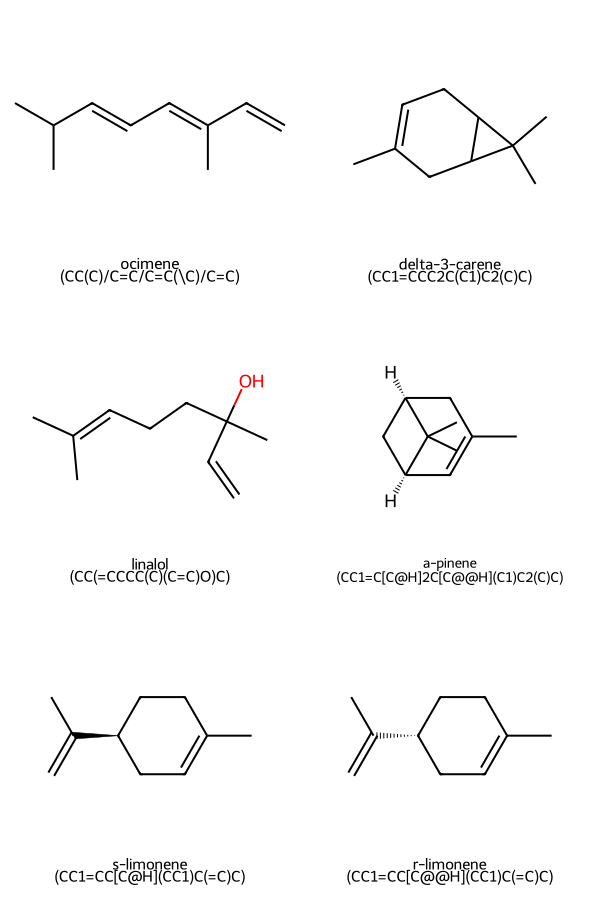

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

unique_df = df.dropna(subset=['SMILES']).drop_duplicates(subset=['SMILES'])
unique_df = unique_df.head(6)

mols = []
legends = []

for index, row in unique_df.iterrows():
    smiles = row['SMILES']
    name = row['cleaned_item']

    mol = Chem.MolFromSmiles(smiles)

    if mol is not None:
        mols.append(mol)
        legends.append(f"{name}\n({smiles})")

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=2,
    subImgSize=(300, 300),
    legends=legends,
    returnPNG=False
)

img

Printing the graph representation of the molecules

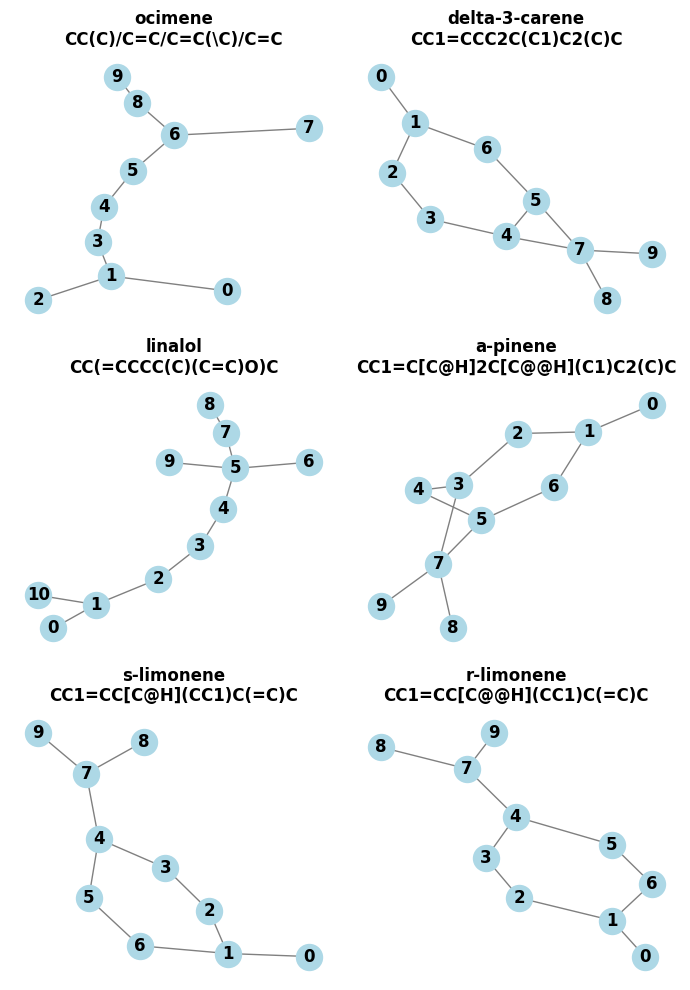

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

fig, axes = plt.subplots(3, 2, figsize=(7, 10))
axes = axes.flatten()
plotted_smiles = set()
plot_idx = 0

for i, graph in enumerate(G):
    smiles = df['SMILES'].iloc[i]
    molecule_name = df['cleaned_item'].iloc[i]

    if smiles not in plotted_smiles and pd.notna(smiles):
        plotted_smiles.add(smiles)
        ax = axes[plot_idx]

        nx.draw(
            graph,
            ax=ax,
            with_labels=True,
            node_color='lightblue',
            node_size=350,
            font_weight='bold',
            edge_color='gray'
        )

        ax.set_title(f"{molecule_name}\n{smiles}", fontsize=12, fontweight='bold')

        plot_idx += 1

        if plot_idx >= 6:
            break

for j in range(plot_idx, 6):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

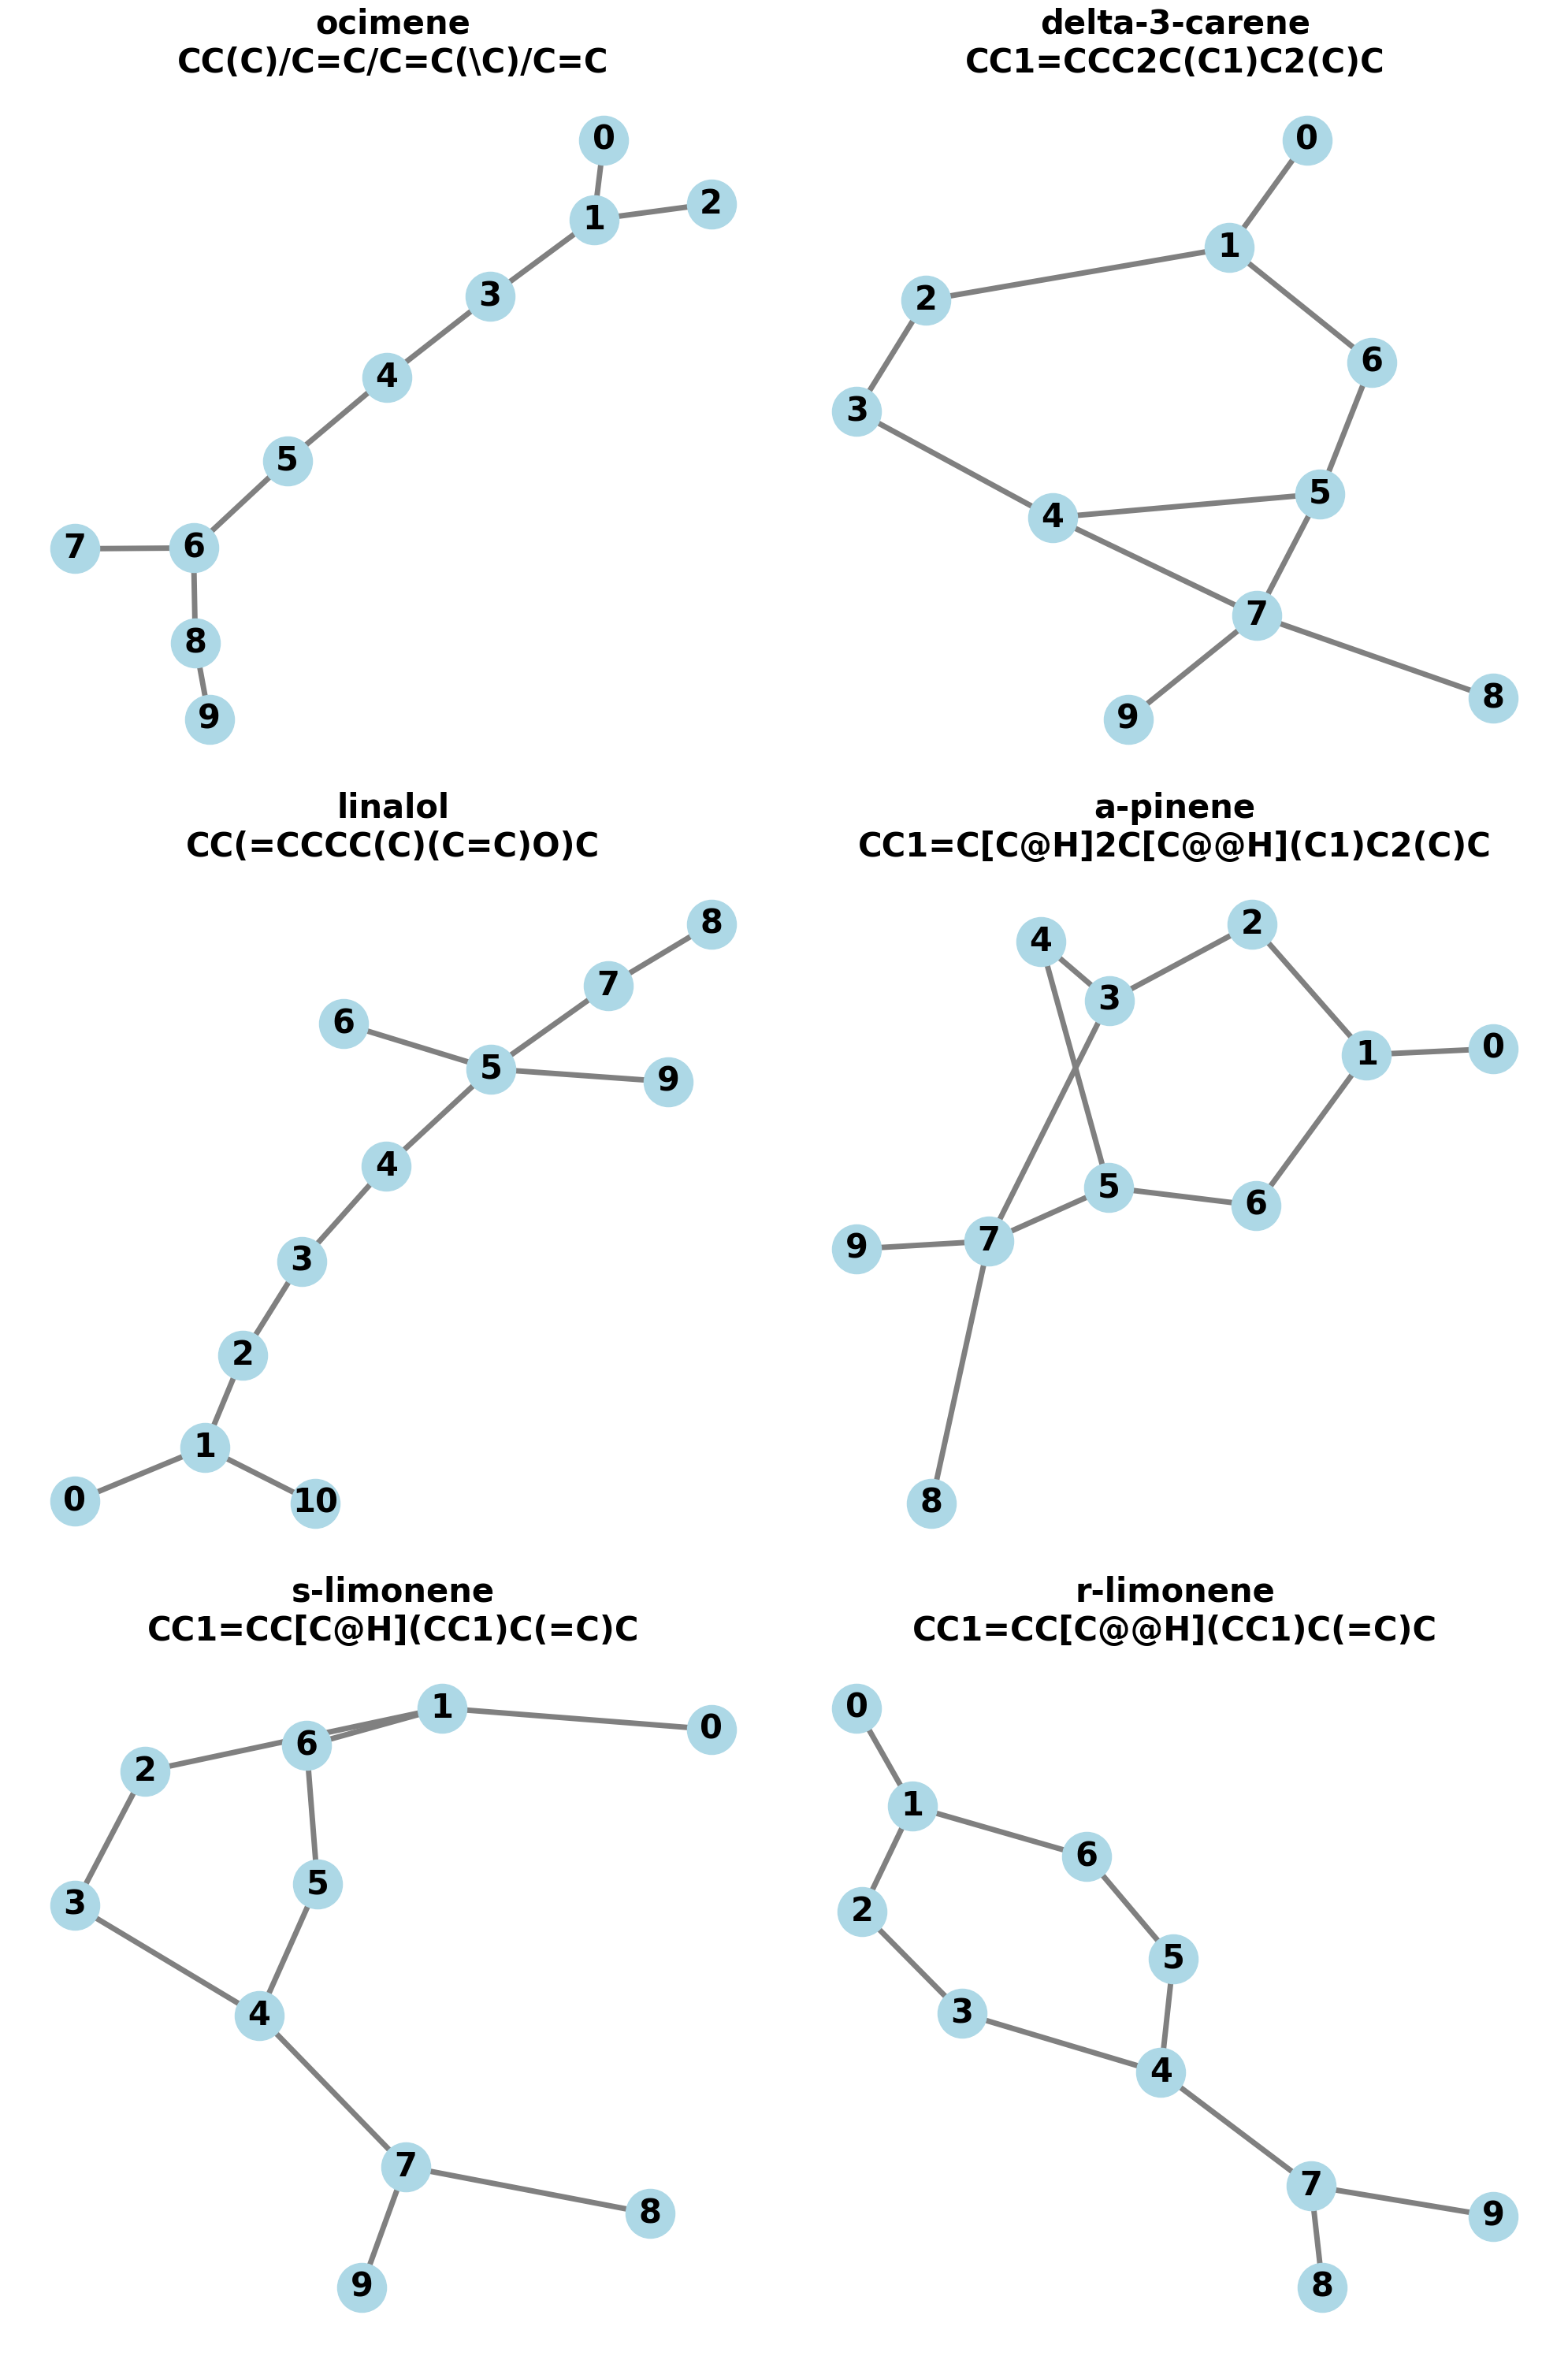

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

fig, axes = plt.subplots(3, 2, figsize=(20, 30))
axes = axes.flatten()
plotted_smiles = set()
plot_idx = 0

for i, graph in enumerate(G):
    smiles = df['SMILES'].iloc[i]
    molecule_name = df['cleaned_item'].iloc[i]

    if smiles not in plotted_smiles and pd.notna(smiles):
        plotted_smiles.add(smiles)
        ax = axes[plot_idx]

        nx.draw(
            graph,
            ax=ax,
            with_labels=True,
            node_color='lightblue',
            node_size=2000,
            font_weight='bold',
            edge_color='gray',
            font_size = 30,
            width = 5
        )

        ax.set_title(f"{molecule_name}\n{smiles}", fontsize=30, fontweight='bold')

        plot_idx += 1

        if plot_idx >= 6:
            break

for j in range(plot_idx, 6):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

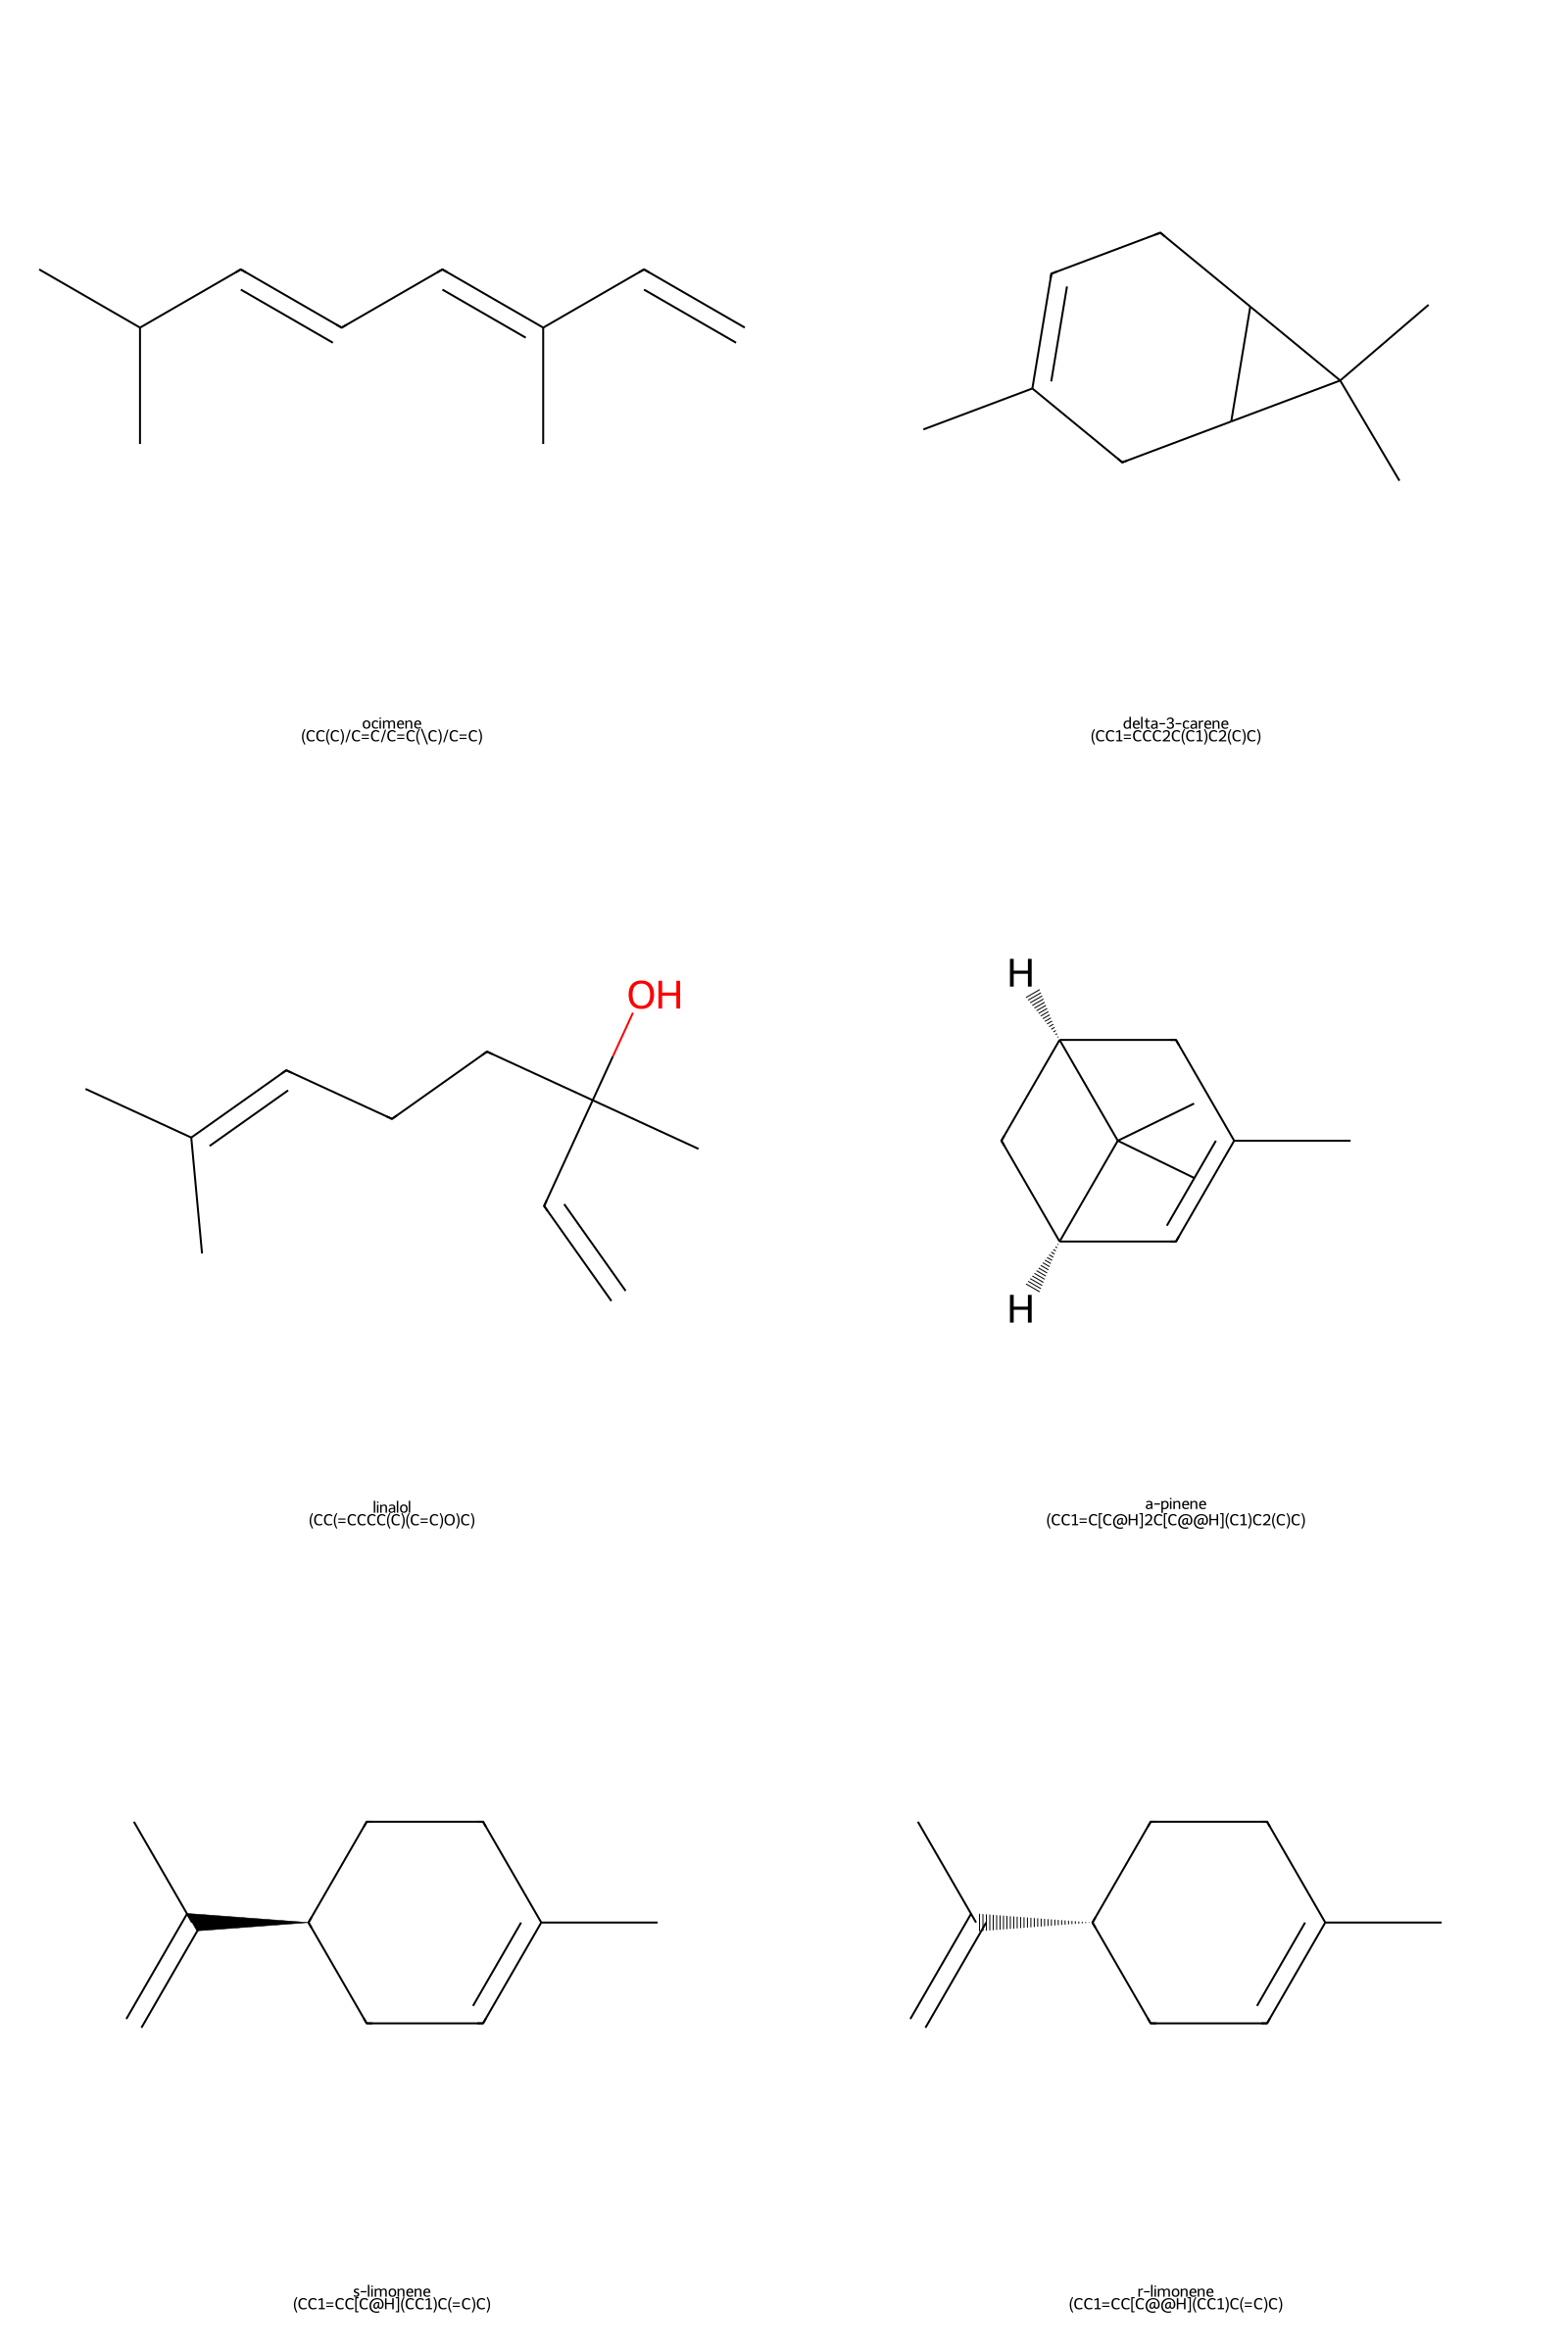

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

unique_df = df.dropna(subset=['SMILES']).drop_duplicates(subset=['SMILES'])
unique_df = unique_df.head(6)

mols = []
legends = []

for index, row in unique_df.iterrows():
    smiles = row['SMILES']
    name = row['cleaned_item']

    mol = Chem.MolFromSmiles(smiles)

    if mol is not None:
        mols.append(mol)
        legends.append(f"{name}\n({smiles})")

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=2,
    subImgSize=(800, 800),
    legends=legends,
    returnPNG=False
)

img